<a href="https://colab.research.google.com/github/ChinmoyBilhor/Brain-Tumor-MRI-Classification-using-DenseNet121/blob/main/Brain_Tumor_MRI_Classification_using_DenseNet121.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Imports**

In [ ]:
import os
import random
import kagglehub
from PIL import Image
!pip install -q split-folders
import splitfolders
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from torchvision.models import densenet121, DenseNet121_Weights


**Dataset Download**

In [ ]:
dataset_path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")
print("Dataset Path:", dataset_path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Dataset Path: /kaggle/input/brain-tumor-mri-dataset


**Dataset Configuration**

In [ ]:
train_dir = os.path.join(dataset_path, "Training")
test_dir = os.path.join(dataset_path, "Testing")
classes = sorted(os.listdir((train_dir)))
print("Classes:", classes)
print("Number of Classes:", len(classes))

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Number of Classes: 4


**Class Distribution**

In [ ]:
print("Training Dataset:")
for cls in classes:
  print(f"{cls}: {len(os.listdir(os.path.join(train_dir, cls)))}")

print("\nTesting Dataset:")
for cls in classes:
  print(f"{cls}: {len(os.listdir(os.path.join(test_dir, cls)))}")

Training Dataset:
glioma: 1400
meningioma: 1400
notumor: 1400
pituitary: 1400

Testing Dataset:
glioma: 400
meningioma: 400
notumor: 400
pituitary: 400


**Class Distribution Visualization**

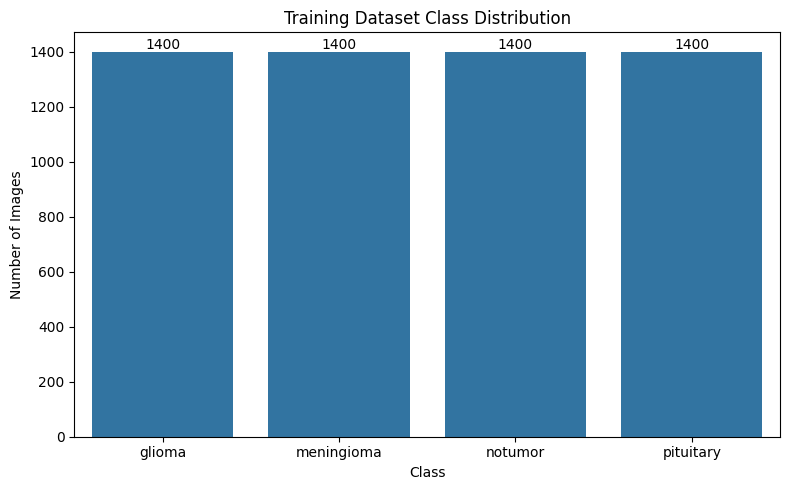

In [ ]:
counts = [len(os.listdir(os.path.join(train_dir, cls))) for cls in classes]
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=classes, y=counts)
ax.bar_label(ax.containers[0])
plt.title("Training Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

**Visualize Sample Images**

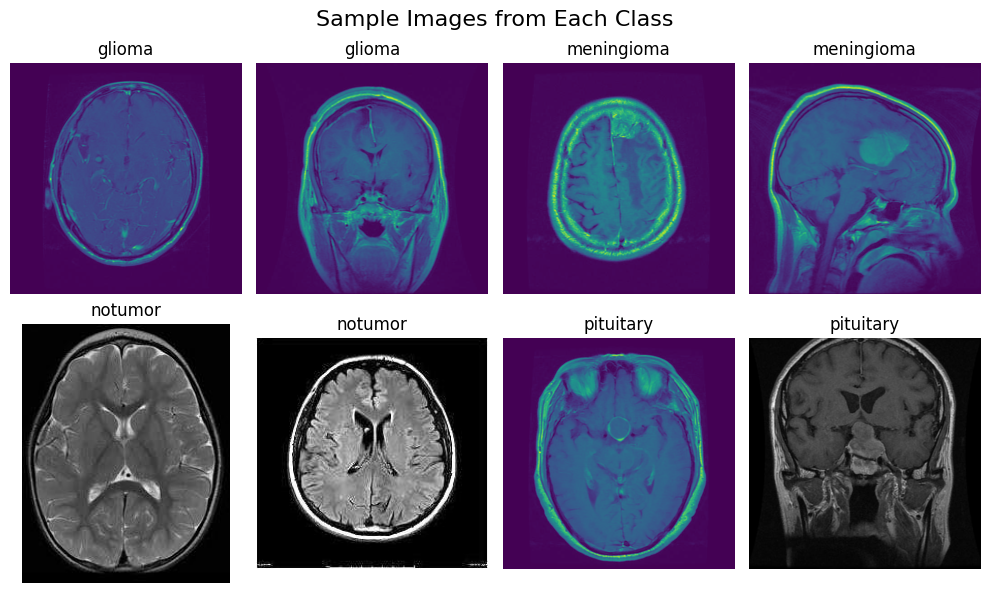

In [ ]:
random.seed(42)
plt.figure(figsize=(10, 6))
k = 1
for cls in classes:
  images = random.sample(os.listdir(os.path.join(train_dir, cls)), 2)
  for img in images:
    plt.subplot(2, 4, k)
    img_path = os.path.join(train_dir, cls, img)
    plt.imshow(Image.open(img_path))
    plt.title(cls)
    plt.axis("off")
    k += 1
plt.suptitle("Sample Images from Each Class", fontsize=16)
plt.tight_layout()
plt.show()

**Sample Image Properties**

In [ ]:
cls_path = os.path.join(train_dir, classes[0])
img_path = os.path.join(cls_path, os.listdir(cls_path)[0])
img = Image.open(img_path)
print(f"Image Size: {img.size}")
print(f"Image Mode: {img.mode}")
print(f"Image Format: {img.format}")

Image Size: (512, 512)
Image Mode: L
Image Format: JPEG


**Image Dimension Analysis**

In [ ]:
img_sizes = []
for cls in classes:
  cls_path = os.listdir(os.path.join(train_dir, cls))
  for img in cls_path:
    img_path = os.path.join(train_dir, cls, img)
    img = Image.open(img_path)
    img_sizes.append(img.size)
print(f"Total Images: {len(img_sizes)}")
print(f"Unique Sizes: {len(set(img_sizes))}")
print(f"Smallest Image: {min(img_sizes)}")
print(f"Largest Image: {max(img_sizes)}")

Total Images: 5600
Unique Sizes: 381
Smallest Image: (150, 198)
Largest Image: (1375, 1446)


**Data Preprocessing and Augmentation**

In [ ]:
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
train_transform = transforms.Compose([transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5), transforms.RandomRotation(degrees=8),
    transforms.RandomAffine(degrees=0, translate=(0.03, 0.03), scale=(0.95, 1.05)),
    transforms.ToTensor(), transforms.Normalize(mean, std)])
test_transform = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor(),
    transforms.Normalize(mean, std)])

**Split the dataset**

In [ ]:
splitfolders.ratio(input = train_dir, output = "data", seed = 42, ratio = (0.8, 0.2))
print("Train-Validation split completed successfully")

Copying files: 5600 files [00:07, 738.65 files/s] 

Train-Validation split completed successfully


**Create Datasets and DataLoaders**

In [ ]:
train_dataset = datasets.ImageFolder("data/train", transform=train_transform)
val_dataset = datasets.ImageFolder("data/val",transform=test_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=test_transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
print(f"Training Images: {len(train_dataset)}")
print(f"Validation Images: {len(val_dataset)}")
print(f"Testing Images: {len(test_dataset)}")
print(f"Classes: {train_dataset.classes}")

Training Images: 4480
Validation Images: 1120
Testing Images: 1600
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


**Model Setup**

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = densenet121(weights=DenseNet121_Weights.DEFAULT)
num_classes = len(train_dataset.classes)
model.classifier = nn.Sequential(nn.Dropout(p=0.3), nn.Linear(model.classifier.in_features,num_classes))
model.to(device)
total_params = sum(p.numel() for p in model.parameters())
print("Device:", device)
print("Model: DenseNet121")
print(f"Parameters: {total_params:,}")

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 223MB/s]


Device: cuda
Model: DenseNet121
Parameters: 6,957,956


**Training Config**

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode = "min",
                                                 factor = 0.5, patience = 2)

**Model Training**

In [ ]:
best_val_loss = float("inf")
patience = 5
counter = 0
train_accuracy_history = []
val_accuracy_history = []
train_loss_history = []
val_loss_history = []
num_epochs = 10
for epoch in range(num_epochs):
  model.train()
  train_loss = train_correct = total = 0
  for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)
    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)
    train_loss += loss.item()
    loss.backward()
    optimizer.step()
    _, predicted = outputs.max(1)
    total += labels.size(0)
    train_correct += (predicted == labels).sum().item()
  train_acc = 100 * train_correct / total
  train_loss = train_loss / len(train_loader)
  train_accuracy_history.append(round(train_acc, 2))
  train_loss_history.append(round(train_loss, 4))

  model.eval()
  val_loss = val_correct = total = 0
  with torch.no_grad():
    for images, labels in val_loader:
      images, labels = images.to(device), labels.to(device)
      outputs = model(images)
      loss = criterion(outputs, labels)
      val_loss += loss.item()
      _, predicted = outputs.max(1)
      total += labels.size(0)
      val_correct += (predicted == labels).sum().item()
  val_acc = 100 * val_correct / total
  val_loss = val_loss / len(val_loader)
  val_accuracy_history.append(round(val_acc, 2))
  val_loss_history.append(round(val_loss, 4))
  scheduler.step(val_loss)

  if val_loss < best_val_loss:
    best_val_loss = val_loss
    counter = 0
  else:
      counter += 1
      print(f"No improvement ({counter}/{patience})")
  if counter >= patience:
        print(f"\nEarly stopping at Epoch {epoch+1}")
        break

  if epoch != 0:
    print()
  print(f"Epoch {epoch+1}/{num_epochs}:")
  print(f"Train Accuracy: {train_acc:.2f}%")
  print(f"Validation Accuracy: {val_acc:.2f}%")
  print(f"Train Loss: {train_loss:.4f}")
  print(f"Validation Loss: {val_loss:.4f}")

Epoch 1/10:
Train Accuracy: 87.43%
Validation Accuracy: 95.45%
Train Loss: 0.3533
Validation Loss: 0.1453

Epoch 2/10:
Train Accuracy: 95.94%
Validation Accuracy: 97.77%
Train Loss: 0.1242
Validation Loss: 0.0702
No improvement (1/5)

Epoch 3/10:
Train Accuracy: 97.83%
Validation Accuracy: 97.41%
Train Loss: 0.0698
Validation Loss: 0.0788

Epoch 4/10:
Train Accuracy: 98.48%
Validation Accuracy: 98.04%
Train Loss: 0.0517
Validation Loss: 0.0696
No improvement (1/5)

Epoch 5/10:
Train Accuracy: 98.79%
Validation Accuracy: 97.77%
Train Loss: 0.0406
Validation Loss: 0.0749

Epoch 6/10:
Train Accuracy: 99.04%
Validation Accuracy: 98.57%
Train Loss: 0.0316
Validation Loss: 0.0516
No improvement (1/5)

Epoch 7/10:
Train Accuracy: 99.29%
Validation Accuracy: 98.30%
Train Loss: 0.0260
Validation Loss: 0.0552
No improvement (2/5)

Epoch 8/10:
Train Accuracy: 99.20%
Validation Accuracy: 98.30%
Train Loss: 0.0246
Validation Loss: 0.0555
No improvement (3/5)

Epoch 9/10:
Train Accuracy: 99.42%
Vali

**Accuracy Curve**

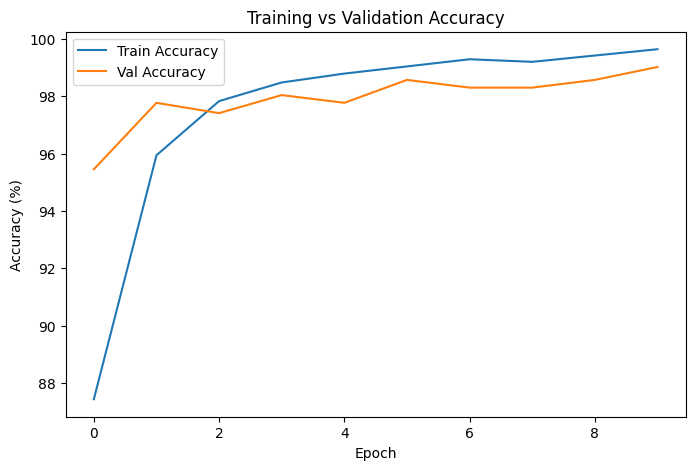

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(train_accuracy_history, label = "Train Accuracy")
plt.plot(val_accuracy_history, label = "Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

**Loss Curve**

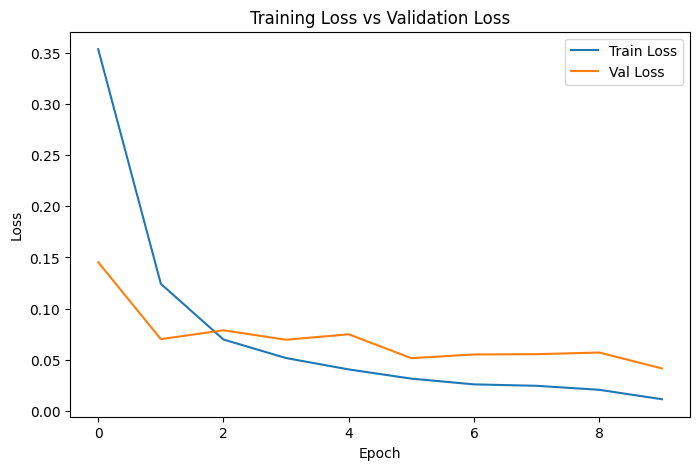

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(train_loss_history, label = "Train Loss")
plt.plot(val_loss_history, label = "Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Validation Loss")
plt.legend()
plt.show()

**Test the Model**

In [ ]:
model.eval()
y_true = []
y_pred = []
test_correct = total = 0
with torch.no_grad():
  for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    outputs = model(images)
    _, predicted = outputs.max(1)
    total += labels.size(0)
    test_correct += (predicted == labels).sum().item()
    y_true.extend(labels.cpu().numpy())
    y_pred.extend(predicted.cpu().numpy())
print(f"Test Accuracy: {round(100 * test_correct / total, 2)}%")

Test Accuracy: 94.94%


**Classification Report**

In [ ]:
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names = test_dataset.classes))

Classification Report:
              precision    recall  f1-score   support

      glioma       1.00      0.82      0.90       400
  meningioma       0.94      0.99      0.96       400
     notumor       0.88      1.00      0.94       400
   pituitary       0.99      0.99      0.99       400

    accuracy                           0.95      1600
   macro avg       0.95      0.95      0.95      1600
weighted avg       0.95      0.95      0.95      1600



**Confusion Matrix**

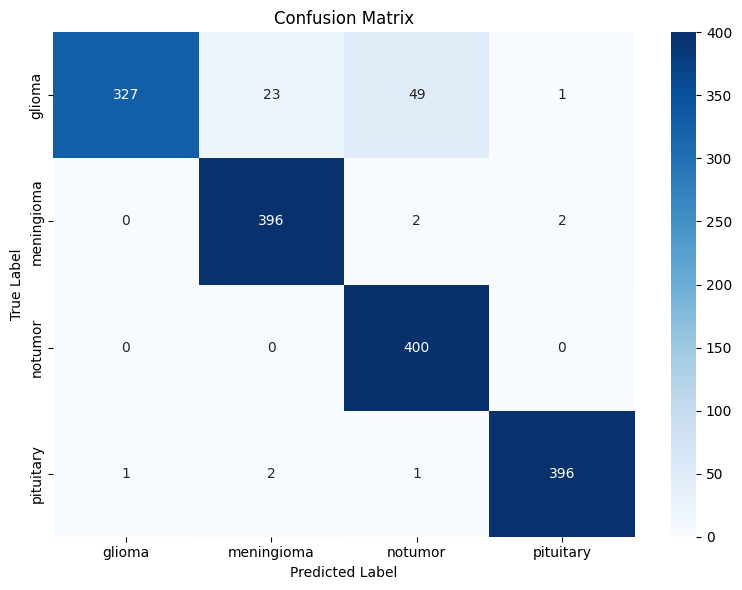

In [ ]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=test_dataset.classes,
    yticklabels=test_dataset.classes)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()